# Fire distribution across Australia

## Accessing Wildfire Data via API

In [2]:
# import necessary libraries
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt


In [3]:
# 1.
# access api url

## satellite: VIIRS SNPP NRT 
## area: 'world' = entire world 
## day range: '1' = data of one day
## date: None = most recent available data, so today's data

MAP_KEY = '4899a992545cbeb46f9fd0b6a025ef17'
area_url ='https://firms.modaps.eosdis.nasa.gov/api/area/csv/' + MAP_KEY + '/VIIRS_SNPP_NRT/world/1' # warum gehen 1, 3 oder 5 tage aber ab 8 oder so nicht mehr??

# 2.
# read in the data from URL

df_area = pd.read_csv(area_url)

# 3.
# have a first glimpse at the data

df_area.head(5)
df_area.shape

(21603, 14)

## Cleaning and Rearranging Data

### Filter for Data only within Australia

In [4]:
# define a bounding box that contains only the area of Australia based on its WGS84 coordinates

coords = [112, -44, 154, -9]

df_aus = df_area[(df_area['longitude'] >= coords[0]) & (df_area['latitude'] >= coords[1]) & (df_area['longitude'] <= coords[2]) & (df_area['latitude'] <= coords[3])].copy()
df_aus.shape
df_aus.head(20)
df_aus.tail()

,latitude,longitude,bright_ti4,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_ti5,frp,daynight
4310,-28.15335,114.62762,347.24,0.47,0.64,2026-05-03,701,N,VIIRS,n,2.0NRT,299.20,11.47,D
4311,-28.15214,114.63242,367.00,0.47,0.64,2026-05-03,701,N,VIIRS,h,2.0NRT,304.88,11.95,D
4312,-28.14623,114.63068,329.44,0.47,0.64,2026-05-03,701,N,VIIRS,n,2.0NRT,299.88,11.95,D
4313,-21.90871,115.22708,348.05,0.71,0.75,2026-05-03,703,N,VIIRS,n,2.0NRT,294.89,10.76,D
4314,-21.90658,115.22294,340.89,0.71,0.75,2026-05-03,703,N,VIIRS,n,2.0NRT,294.31,6.30,D


### Filter for required Timeframe

In [5]:
# 1. 
# combine the acq_date and acq_time column to one acq_datetime column and set it to an active time format with pandas function to_datetime

## acq_date is a string in the format YYYY-MM_DD, 
## while acq_time is an integer in Greenwich Mean Time (e.g. 603 meaning 6:03), 
## so it needs to be converted to string too (with astype(str)),
## fill it up to 4 numbers with zeros, so that all times have the same length (with str.zfill(4), e.g. 603 -> 0603)
## and save it as the format '%Y-%m-%d %H%M'

df_aus['acq_datetime'] = pd.to_datetime(df_aus['acq_date'] + ' ' + df_aus['acq_time'].astype(str).str.zfill(4), format='%Y-%m-%d %H%M')
df_aus.head()

print (f'Australia GMT timezone datetime value range: {df_aus['acq_datetime'].min()} to {df_aus['acq_datetime'].max()}')

# 2.
# convert GMT into local time?

# 3.
# # Set the timestamp column as the index ?
###hourly_data = hourly_data.set_index("timestamp")

# Notice how 'timestamp' drops down a level to become the index!
###display(hourly_data.head(3))


Australia GMT timezone datetime value range: 2026-05-03 03:38:00 to 2026-05-03 07:03:00


### Converting raw coordinates into geometries

In [6]:
# the projection EPSG:9473 is used for Australia, as it is recommended for national mapping

# convert latitude, longitude values into point geometry and set crs (since no crs extisting yet) with crs="EPSG:9473" to EPSG:9473

gdf_aus = gpd.GeoDataFrame(
    df_aus, geometry=gpd.points_from_xy(df_aus.longitude, df_aus.latitude), crs="EPSG:9473")
print(gdf_aus.crs)
gdf_aus.head()

EPSG:9473


,latitude,longitude,bright_ti4,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_ti5,frp,daynight,acq_datetime,geometry
988,-37.90232,142.86154,345.11,0.43,0.62,2026-05-03,338,N,VIIRS,n,2.0NRT,287.45,4.77,D,2026-05-03 03:38:00,POINT (142.862 -37.902)
989,-37.48530,149.62840,327.05,0.56,0.43,2026-05-03,338,N,VIIRS,n,2.0NRT,294.02,3.86,D,2026-05-03 03:38:00,POINT (149.628 -37.485)
990,-35.79145,149.52910,334.74,0.54,0.42,2026-05-03,338,N,VIIRS,n,2.0NRT,287.94,6.27,D,2026-05-03 03:38:00,POINT (149.529 -35.791)
991,-35.78898,149.52823,333.41,0.54,0.42,2026-05-03,338,N,VIIRS,n,2.0NRT,286.50,5.79,D,2026-05-03 03:38:00,POINT (149.528 -35.789)
992,-30.69276,147.75650,328.82,0.39,0.44,2026-05-03,340,N,VIIRS,n,2.0NRT,273.63,1.96,D,2026-05-03 03:40:00,POINT (147.756 -30.693)


## Calculating means etc?

## Visualise it and create interactive Map

In [9]:
from folium.plugins import TimestampedGeoJson
import folium

# create basemap for the extent of Australia
aus_map = folium.Map(
    location=[-25.5649, 133.1234], # use the coordinates of Australia's centre (25°56′49.3″S, 133°12′34.7″E) for the location
    zoom_start=4,
    tiles="CartoDB Positron",  # clean, light basemap
)
# add the raw GeoDataFrame to the map as a GeoJSON layer, does not work with datetime column!!
# folium.GeoJson(gdf_aus).add_to(aus_map)
# instead:
features = []

for _, row in gdf_aus.iterrows():
    features.append({
        "type": "Feature",
        "geometry": row["geometry"].__geo_interface__,
        "properties": {
            "time": row["acq_datetime"].isoformat(),
            "popup": "wild fire",
            "icon": "marker",
            "iconstyle": {
                "iconUrl": "https://images.openai.com/static-rsc-4/GtBDs7oLJVnALsmMzbDiEGVH88d0ar_I1MJPnscyB6j9ThWQ8ja3sbhDtzibtrVMAN-39doPT2nwxlGPTkQaZhkFYBjb2NlRVydJIr3M9lQBKwpuNZUV45SLAPOlVias2cRopqtyiVL16OARmX-Tnn-isaaP2aC2tRSkwU2cn0q59PUYFh4jBwQlYqpG6nIZ?purpose=inliner",
                "iconSize": [20, 20]
            }
        }}
    )

TimestampedGeoJson(
    {
        "type": "FeatureCollection",
        "features": features
    },
    period="PT1H",  # Zeitauflösung
    add_last_point=True
).add_to(aus_map)
## wie kann ich machen dass alte brände wieder verschwinden, karte addiert derzeit alle brände
# display the map 
aus_map

Note: you may need to restart the kernel to use updated packages.


(-44.0, -9.0)

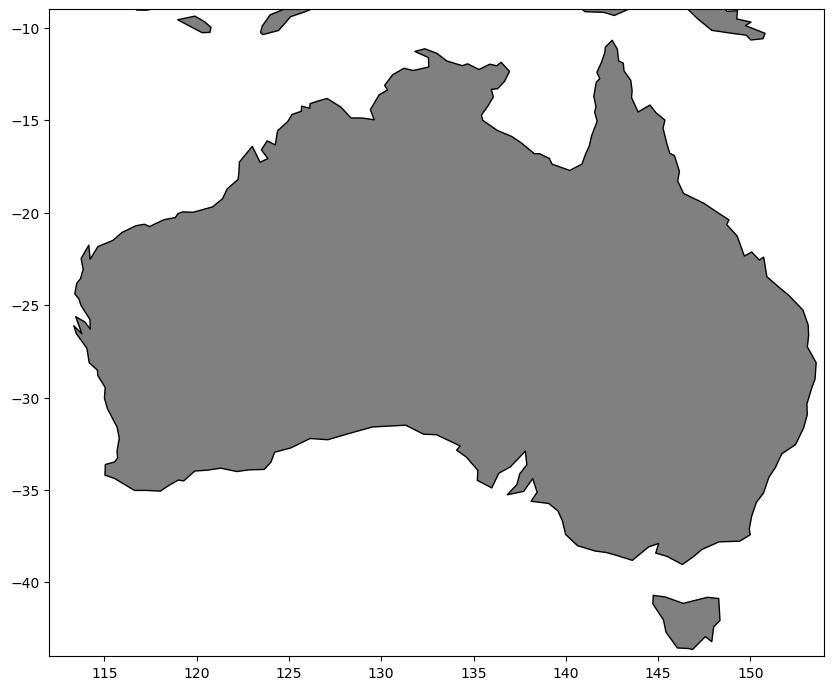

In [8]:
# alternative way: ?
%pip install geodatasets cartopy
from cartopy import crs as ccrs
from geodatasets import get_path

path = get_path("naturalearth.land")
world = gpd.read_file(path)

ax = world.plot(figsize=(10, 10), color="grey", edgecolor="black")
ax.set_xlim([coords[0],  coords[2]])
ax.set_ylim([coords[1],  coords[3]])